# Goal

We can think of the final mode choice in a random utility framework as:

$$
U_{im}
= \beta_{\text{time}} \cdot \mathbb{E}[\text{TT}_{im}]
+ \beta_{\text{uncert}} \cdot \text{SD}(\text{TT}_{im})
+ \beta_{\text{cost}} \cdot \text{Cost}_{im}
+ \varepsilon_{im}
$$

Where:

- $i$  
  - Index for the individual (agent).

- $m$  
  - Index for the mode (e.g., car, bus).

- $U_{im}$  
  - Latent utility (or negative generalized disutility) that individual $i$ associates with mode $m$.

- $\mathbb{E}[\text{TT}_{im}]$  
  - Expected travel time for individual $i$ using mode $m$ (e.g., in minutes), coming from their belief/learning process.

- $\text{SD}(\text{TT}_{im})$  
  - Standard deviation (uncertainty) of travel time for individual $i$ using mode $m$, also derived from beliefs.

- $\text{Cost}_{im}$  
  - Monetary cost associated with using mode $m$ for individual $i$ (e.g., tolls, fares, etc.).

- $\beta_{\text{time}}$  
  - Coefficient measuring marginal (dis)utility per unit of expected travel time.

- $\beta_{\text{uncert}}$  
  - Coefficient measuring marginal (dis)utility per unit of travel time uncertainty.

- $\beta_{\text{cost}}$  
  - Coefficient measuring marginal (dis)utility per unit of monetary cost.

- $\varepsilon_{im}$  
  - Random taste shock capturing unobserved factors; in a logit model this would typically be i.i.d. Gumbel.





## Units summary for the belief and utility functions

### 1. `compute_experience_beliefs`

**Inputs (conceptual units):**
- `travel_data`: sequence of `(day, travel_time)`
  - `day_i`: dimensionless day index (e.g. 0, 1, 2, …)
  - `travel_time_i`: **minutes**
- `current_day`: same units as `day_i` (dimensionless day index)
- `time_decay_rate`: **per day** (e.g. 0.1 / day in an exponential decay)
- `travel_time_prior`: **minutes**
- `prior_weight`: dimensionless (pseudo-count / effective weight)

**Outputs:**
- `expected_travel_time`: **minutes**  
- `travel_time_uncertainty`: **minutes**  
  (interpreted as the standard deviation of the belief about travel time)

---

### 2. `compute_generalized_cost`

**Inputs (conceptual units):**
- `expected_travel_time`: **minutes**  
  - Belief about mean travel time for this mode on this day.
- `travel_time_uncertainty`: **minutes**  
  - Belief about uncertainty in travel time (e.g., standard deviation).
- `uncertainty_multiplier`: dimensionless  
  - Scales how much uncertainty contributes to “effective minutes” (can be positive, negative, or zero).
- `value_of_time`: **money per minute** (e.g. dollars/minute)  
  - Converts effective minutes into monetary units.
- `experience_weight`: dimensionless  
  - Mode-/agent-specific factor (λₘ) that rescales perceived minutes in this mode.
- `toll`: **money** (e.g. dollars)  
  - Monetary toll or fare for this mode on this day.

**Outputs:**
- `generalized_cost`: **money**  
  - Total generalized cost $C_m(t)$ in monetary units; this is the quantity compared across modes (choose the mode with lower `generalized_cost`).


# Imports

In [371]:
from math import exp, sqrt
from typing import Sequence, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product

import numpy as np
from scipy.stats import lognorm, skewnorm


pd.set_option("display.max_rows", 100)  
pd.set_option("display.max_columns", None)


# step one: compute expected value and variance of future outcomes given current beliefs

In [372]:
def compute_experience_beliefs(
    travel_data,
    current_day,
    time_decay_rate,
    travel_time_prior,
    prior_weight,
    staleness_scale=0.05,   # how fast uncertainty grows with staleness
):
    if travel_data:
        days, tts = zip(*travel_data)
        days      = np.array(days, dtype=float)
        tts       = np.array(tts,  dtype=float)

        ages      = current_day - days
        weights   = np.exp(-time_decay_rate * ages)
        W         = float(weights.sum())

        if W > 0:
            mu_data = float((weights * tts).sum() / W)
        else:
            mu_data = travel_time_prior

        total_weight = prior_weight + W
        expected_tt  = (prior_weight * travel_time_prior + W * mu_data) / total_weight

        # base uncertainty ~ 1 / effective sample size
        base_unc = 1.0 / max(total_weight, 1e-8)

        # staleness: time since last observation
        last_day  = float(days.max())
        staleness = max(current_day - last_day, 0.0)

    else:
        # no data at all
        W           = 0.0
        total_weight= prior_weight
        expected_tt = travel_time_prior
        base_unc    = 1.0 / max(total_weight, 1e-8)
        staleness   = float(current_day)   # haven't used this mode since day 0

    # inflate uncertainty with staleness
    travel_time_uncertainty = base_unc * (1.0 + staleness_scale * staleness)

    return expected_tt, travel_time_uncertainty

def compute_generalized_cost(
    expected_travel_time,
    travel_time_uncertainty,
    uncertainty_multiplier,   # >0 means more exploration
    value_of_time,
    experience_weight,
    toll,
):
    effective_tt = expected_travel_time - uncertainty_multiplier * travel_time_uncertainty
    return value_of_time * experience_weight * effective_tt + toll



# step two: compute utility of mode based on beliefs and preferences

(<Figure size 640x480 with 2 Axes>,
 (<Axes: title={'center': 'Beliefs and slow prior (λ=0.2, prior_w=0.2, η=0.05)'}, xlabel='Day', ylabel='Travel time'>,
  <Axes: ylabel='Effective weight W'>))

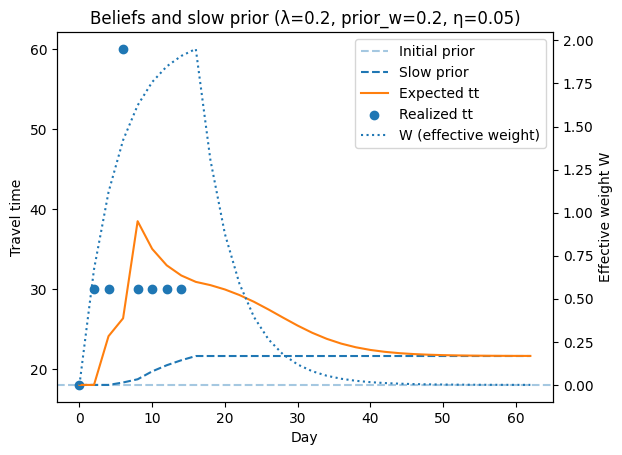

In [378]:
import numpy as np
import matplotlib.pyplot as plt

def slow_prior_update(prior, exp_tt, eta=0.05):
    return prior + eta * (exp_tt - prior)

def plot_belief_trajectory(
    time_decay_rate,
    prior_weight,
    prior,
    tt_history,        # list of ints/floats, Nones allowed
    day_spacing=1,
    eta=0.01,          # slow prior learning rate
):
    travel_data = []
    days, exp_tts, obs_days, obs_tts, Ws, priors = [], [], [], [], [], []

    prior_t = prior

    for i, tt in enumerate(tt_history):
        day = i * day_spacing

        # beliefs using current slow prior
        exp_tt, _ = compute_experience_beliefs(
            travel_data       = travel_data,
            current_day       = day,
            time_decay_rate   = time_decay_rate,
            travel_time_prior = prior_t,
            prior_weight      = prior_weight,
        )

        # effective weight W (sum of decayed weights, no prior)
        if travel_data:
            d_obs   = [d for d, _ in travel_data]
            ages    = [day - d for d in d_obs]
            weights = np.exp(-time_decay_rate * np.array(ages))
            W = float(weights.sum())
        else:
            W = 0.0

        days.append(day); exp_tts.append(exp_tt); Ws.append(W); priors.append(prior_t)

        if tt is not None:
            obs_days.append(day); obs_tts.append(tt)
            travel_data.append((day, tt))
            # slow prior update only when we actually observe a trip
            prior_t = slow_prior_update(prior_t, exp_tt, eta=eta)

    fig, ax1 = plt.subplots()

    ax1.axhline(prior, linestyle="--", alpha=0.4, label="Initial prior")
    ax1.plot(days, priors, linestyle="--", label="Slow prior")
    ax1.plot(days, exp_tts, label="Expected tt")
    ax1.scatter(obs_days, obs_tts, label="Realized tt")

    ax1.set_xlabel("Day")
    ax1.set_ylabel("Travel time")

    ax2 = ax1.twinx()
    ax2.plot(days, Ws, linestyle=":", label="W (effective weight)")
    ax2.set_ylabel("Effective weight W")

    # combined legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="best")

    ax1.set_title(f"Beliefs and slow prior (λ={time_decay_rate}, prior_w={prior_weight}, η={eta})")

    return fig, (ax1, ax2)


plot_belief_trajectory(
    time_decay_rate=0.2, 
    prior_weight=0.2, 
    prior=18.0,
    tt_history=[18, 30, 30, 60, 30, 30,30,30, None, None,None, None, None, None, None, None, None, None, None, None, None, None,None, None, None, None, None, None, None, None, None, None ],
    day_spacing=2,
    eta=0.05,
)


#[30,30, 30,30,30,30,30,30,30,30,30,30,30,30,30,30,30, 30,30,30,30,30,30,30,30,30,30,30,30,30, None, None, None, None, None, None, None, None,None, None, None,None, None, None, None, None, None, None, None,None, None, None],

# fake person agent

In [374]:


class LightweightPerson2:
    def __init__(
        self,
        person_id,
        value_of_time_hour=None,      # if None -> lognormal draw
        experience_weight_bus=None,   # if None -> skewnorm draw
        experience_weight_car=1.0,
        prior_car=22.0,
        prior_bus=50.0,
        time_decay_rate=0.2,
        prior_weight=0.2,
        uncertainty_multiplier=3.0,   # exploration strength
        eta=0.05,                     # slow prior learning rate
    ):
        self.person_id = person_id

        self.value_of_time_hour = (lognorm(s=0.64, scale=40).rvs() if value_of_time_hour is None else value_of_time_hour)
        self.value_of_time      = self.value_of_time_hour / 60.0  # $/min

        self.experience_weight_car = experience_weight_car
        self.experience_weight_bus = (skewnorm(6, loc=1.15, scale=0.3).rvs() if experience_weight_bus is None else experience_weight_bus)

        self.prior_car        = prior_car
        self.prior_bus        = prior_bus
        self.time_decay_rate  = time_decay_rate
        self.prior_weight     = prior_weight
        self.uncertainty_multiplier = uncertainty_multiplier
        self.eta              = eta

        self.history_car, self.history_bus, self.records = [], [], []

    # ---------- helpers ----------

    def _history_prior_weight(self, mode):
        if mode == "car":
            return self.history_car, self.prior_car, self.experience_weight_car
        else:
            return self.history_bus, self.prior_bus, self.experience_weight_bus

    # ---------- beliefs & costs ----------
    def _slow_prior_update(self, prior, exp_tt):
        return prior + self.eta * (exp_tt - prior)


    def get_beliefs(self, mode, day):
        hist, prior, _ = self._history_prior_weight(mode)
        return compute_experience_beliefs(
            travel_data       = hist,
            current_day       = day,
            time_decay_rate   = self.time_decay_rate,
            travel_time_prior = prior,
            prior_weight      = self.prior_weight,
        )

    def compute_cost(self, mode, day, toll):
        etc, unc = self.get_beliefs(mode, day)
        _, _, exp_w = self._history_prior_weight(mode)
        return compute_generalized_cost(
            expected_travel_time     = etc,
            travel_time_uncertainty  = unc,
            uncertainty_multiplier   = self.uncertainty_multiplier,
            value_of_time            = self.value_of_time,
            experience_weight        = exp_w,
            toll                     = toll,
        )

    # ---------- decision & learning ----------

    def decide_mode(self, day, toll_car, toll_bus):
        etc_car, unc_car = self.get_beliefs("car", day)
        etc_bus, unc_bus = self.get_beliefs("bus", day)

        c_car = compute_generalized_cost(
            expected_travel_time     = etc_car,
            travel_time_uncertainty  = unc_car,
            uncertainty_multiplier   = self.uncertainty_multiplier,
            value_of_time            = self.value_of_time,
            experience_weight        = self.experience_weight_car,
            toll                     = toll_car,
        )
        c_bus = compute_generalized_cost(
            expected_travel_time     = etc_bus,
            travel_time_uncertainty  = unc_bus,
            uncertainty_multiplier   = self.uncertainty_multiplier,
            value_of_time            = self.value_of_time,
            experience_weight        = self.experience_weight_bus,
            toll                     = toll_bus,
        )

        take_car = (c_car < c_bus)
        return take_car, etc_car, unc_car, etc_bus, unc_bus, c_car, c_bus

    def update_history(self, day, take_car, tt):
        if take_car:
            self.history_car.append((day, tt))
        else:
            self.history_bus.append((day, tt))

    def step_and_record(self, day, toll_car, toll_bus, true_tt_car, true_tt_bus):
        take_car, etc_car, unc_car, etc_bus, unc_bus, c_car, c_bus = self.decide_mode(day, toll_car, toll_bus)

        realized_tt = true_tt_car if take_car else true_tt_bus
        self.update_history(day, take_car, realized_tt)

        # slow prior update for the chosen mode
        if self.eta > 0.0:
            if take_car:
                self.prior_car = self._slow_prior_update(self.prior_car, etc_car)
            else:
                self.prior_bus = self._slow_prior_update(self.prior_bus, etc_bus)

        row = {
            "person_id": self.person_id,
            "day": day,
            "take_car": take_car,
            "expected_tt_car": etc_car,
            "expected_tt_bus": etc_bus,
            "uncertainty_tt_car": unc_car,
            "uncertainty_tt_bus": unc_bus,
            "cost_car": c_car,
            "cost_bus": c_bus,
            "toll_car": toll_car,
            "toll_bus": toll_bus,
            "true_tt_car": true_tt_car,
            "true_tt_bus": true_tt_bus,
            "realized_tt": realized_tt,
            "prior_car": self.prior_car,
            "prior_bus": self.prior_bus,
            "prior_weight": self.prior_weight,
            "value_of_time_hour": self.value_of_time_hour,
            "value_of_time_per_min": self.value_of_time,
            "experience_weight_car": self.experience_weight_car,
            "experience_weight_bus": self.experience_weight_bus,
            "uncertainty_multiplier": self.uncertainty_multiplier,
            "time_decay_rate": self.time_decay_rate,
            "eta": self.eta,
        }
        self.records.append(row)
        return row




# Simulate one person many days

In [ ]:
def simulate_single_person(
    person,
    n_days,
    toll_car_schedule,
    toll_bus_schedule,
    tt_car_schedule,
    tt_bus_schedule,
    start_day=0,
    ):
    
    person.records = []
    for day in range(start_day, start_day + n_days):
        person.step_and_record(
            day=day,
            toll_car=toll_car_schedule(day),
            toll_bus=toll_bus_schedule(day),
            true_tt_car=tt_car_schedule(day),
            true_tt_bus=tt_bus_schedule(day),
        )
    return pd.DataFrame(person.records)

In [376]:
rng = np.random.default_rng(0)

def toll_car_schedule(day):  return 15  # car toll jumps after day 20
def toll_bus_schedule(day):  return 0                             # flat bus fare

def tt_car_schedule(day):    return float(rng.normal(loc=50, scale=6))   # car ~ N(35, 6^2) min
def tt_bus_schedule(day):    return float(rng.normal(loc=50, scale=4))   # bus ~ N(45, 4^2) min

person = LightweightPerson2(person_id=1, uncertainty_multiplier=1.5, experience_weight_bus=1, prior_car=40)   # draws VOT and bus weight from your distributions

single_person_season = simulate_single_person(
    person          = person,
    n_days          = 180,
    toll_car_schedule = toll_car_schedule,
    toll_bus_schedule = toll_bus_schedule,
    tt_car_schedule   = tt_car_schedule,
    tt_bus_schedule   = tt_bus_schedule,
    start_day       = 0,
)

single_person_season.head()

single_person_season['take_car'].mean()

0.03888888888888889

(<Figure size 640x480 with 2 Axes>,
 (<Axes: title={'center': 'Car vs Bus cost + choices over time'}, xlabel='Day', ylabel='Generalized cost (dollars)'>,
  <Axes: ylabel='Chosen mode'>))

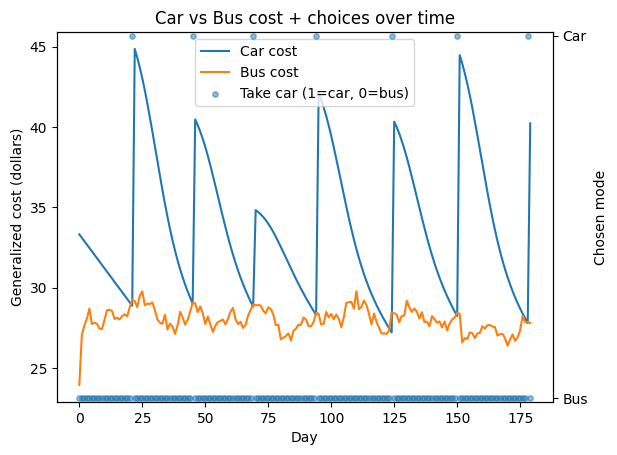

In [377]:
def plot_cost_trajectory(df, title=None):
    days     = df["day"].values
    cost_car = df["cost_car"].values
    cost_bus = df["cost_bus"].values
    take_car = df["take_car"].values.astype(int)

    fig, ax1 = plt.subplots()

    ax1.plot(days, cost_car, label="Car cost")
    ax1.plot(days, cost_bus, label="Bus cost")
    ax1.set_xlabel("Day")
    ax1.set_ylabel("Generalized cost (dollars)")

    if title is None:
        title = "Car vs Bus cost + choices over time"
    ax1.set_title(title)

    ax2 = ax1.twinx()
    ax2.scatter(days, take_car, s=15, alpha=0.5, label="Take car (1=car, 0=bus)")
    ax2.set_ylim(- .01, 1.01)
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(["Bus", "Car"])
    ax2.set_ylabel("Chosen mode")

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="best")

    return fig, (ax1, ax2)


plot_cost_trajectory(single_person_season)



# Single person data collect

# Grid search 


searches through a defined list of perams
runs the record data method on each person
creates a df that can be analyzed

currently looking a the proportion of people who chose car 

In [ ]:


def grid_search_person_decisions(
    param_grid,
    base_person_kwargs=None,
    base_decision_kwargs=None,
    ):
    """
    param_grid: dict mapping param name -> list of values, e.g.
        {
            "value_of_time": [0.3, 0.5],
            "experience_weight_bus": [0.8, 1.2],
            "uncertainty_multiplier": [-0.5, 0.5],
            "day": [0, 1],
            "toll_car": [0.0, 5.0],
            "toll_bus": [0.0],
        }

    base_person_kwargs: fixed kwargs for LightweightPerson (used if not in param_grid).
    base_decision_kwargs: fixed kwargs for record_data (used if not in param_grid).
    """
    if base_person_kwargs is None:
        base_person_kwargs = {}
    if base_decision_kwargs is None:
        base_decision_kwargs = {}

    keys = list(param_grid.keys())
    rows = []

    decision_keys = {"day", "toll_car", "toll_bus"}

    for i, values in enumerate(product(*[param_grid[k] for k in keys])):
        params = dict(zip(keys, values))

        # Split into person init params vs decision params
        person_params = {k: v for k, v in params.items() if k not in decision_keys}
        decision_params = {k: v for k, v in params.items() if k in decision_keys}

        person_kwargs = {**base_person_kwargs, **person_params}
        decision_kwargs = {**base_decision_kwargs, **decision_params}

        p = LightweightPerson(person_id=i, **person_kwargs)            # < ---------------- this is where the person is created
        row = p.record_data(**decision_kwargs)                         # < ---------------- this is where data is recorded

        # also include the grid params explicitly (in case record_data doesn't)
        row.update(params)
        rows.append(row)

    return pd.DataFrame(rows)


In [344]:
wage_dist = lognorm(s=0.64 , scale=40 )  # this is a distribution of wages in $/hr for skiers in salt lake city
exp_weight_bus_dist = skewnorm(6, loc=1.15, scale=0.3)  # how much worse bus minutes feel compared to car minutes

param_grid = {
    "value_of_time": list(wage_dist.rvs(size=200)),
    "experience_weight_bus": list(exp_weight_bus_dist.rvs(size=10)),
    "uncertainty_multiplier": [-0.5, 0, 0.5],
    "day": [0],
    "toll_car": [0.0, 5.0, 10, 15, 20,25, 30,35,40,45, 50],
    "time_decay_rate": [0.1, .01, .2],
}

base_person_kwargs = {
    "prior_car": 22.0,
    "prior_bus": 60.0,
    "experience_weight_car": 1.0,
    "prior_weight": 1.0,
}

base_decision_kwargs = {"day":0, "toll_bus":0.0}  # nothing fixed here, but could be

df = grid_search_person_decisions(
    param_grid=param_grid,
    base_person_kwargs=base_person_kwargs,
    base_decision_kwargs=base_decision_kwargs,
)


print(len(df))
df.head()


198000


,person_id,take_car,prior_car,prior_bus,value_of_time,experience_weight_car,experience_weight_bus,uncertainty_multiplier,time_decay_rate,prior_weight,day,expected_tt_car,uncertainty_tt_car,expected_tt_bus,uncertainty_tt_bus,cost_car,cost_bus,toll_car,toll_bus,history_car,history_bus
0,0,True,22.0,60.0,20.489194,1.0,2.067766,-0.5,0.10,1.0,0,22.0,1.0,60.0,1.0,7.683448,42.719907,0.0,0.0,[],[]
1,1,True,22.0,60.0,20.489194,1.0,2.067766,-0.5,0.01,1.0,0,22.0,1.0,60.0,1.0,7.683448,42.719907,0.0,0.0,[],[]
2,2,True,22.0,60.0,20.489194,1.0,2.067766,-0.5,0.20,1.0,0,22.0,1.0,60.0,1.0,7.683448,42.719907,0.0,0.0,[],[]
3,3,True,22.0,60.0,20.489194,1.0,2.067766,-0.5,0.10,1.0,0,22.0,1.0,60.0,1.0,12.683448,42.719907,5.0,0.0,[],[]
4,4,True,22.0,60.0,20.489194,1.0,2.067766,-0.5,0.01,1.0,0,22.0,1.0,60.0,1.0,12.683448,42.719907,5.0,0.0,[],[]


In [150]:
df.groupby(["toll_car"])["take_car"].mean()


toll_car
0.0     1.000000
5.0     0.999500
10.0    0.970000
15.0    0.916333
20.0    0.832500
25.0    0.741500
30.0    0.653000
35.0    0.563667
40.0    0.474333
45.0    0.404000
50.0    0.342500
Name: take_car, dtype: float64